# 06 — k-Nearest Neighbors (kNN)


kNN is the laziest algorithm in the book: it doesn't *learn* a model during
training — it just memorises the data, and at prediction time it asks "what
are the most similar rows I've already seen, and what was their answer?"
That simplicity makes it the perfect lens for two ideas that matter for every
distance‑based model: **scaling** and the **curse of dimensionality**.

## What you'll be able to do after this notebook

1. Explain in plain words how kNN classifies and regresses.
2. Choose a **distance metric** (Euclidean, Manhattan, cosine) and know when
 each matters.
3. Pick **k** deliberately — with the elbow method and cross‑validation, not a
 guess.
4. See why **feature scaling is mandatory** for kNN (§1.2) and what breaks
 if you skip it.
5. Recognise the **curse of dimensionality** — the failure case where kNN
 silently falls apart as features multiply.

## The process

```mermaid
flowchart TD
 E["EDA: are classes separable in feature space?<br/><small>scatterplots</small>"] --> SC
 SC["Scale the features<br/> non‑negotiable for kNN — §1.2"] --> K
 K["Pick k via CV<br/><small>try a range, watch validation score</small>"] --> V
 V["Evaluate with proper CV<br/><small>notebook 05</small>"] --> S
 S["Sanity‑check: would this survive more features?<br/><small>curse of dim. check</small>"]
```

## 1. The idea, in plain language

To predict the answer for a new row, kNN:

1. **Measures distance** from the new row to every row in the training set.
2. **Picks the k nearest** (smallest distance) — the "neighbors".
3. **Votes**: for classification, majority class among the neighbors; for
 regression, the (often distance‑weighted) average of their targets.

That's it. There's no training step — the "model" *is* the training data. This
makes kNN:

- **Simple** and interpretable ("it predicted Yes because 4 of its 5 nearest
 neighbors were Yes").
- **Slow at prediction time** on large data (every prediction scans all
 training rows; production systems use approximate nearest‑neighbor indexes
 like FAISS/HNSW to fix this).
- **Extremely sensitive to feature scale and irrelevant features** — which is
 the whole story of this notebook.

> **Vocabulary (§0):** "nearest" here means *smallest distance under some
> metric*. "Distance" is the same spread idea as §1.2, generalised to many
> dimensions.

## 2. Distance metrics — the engine under the hood

For two rows $x, y$ with $p$ features:

| Metric | Formula | When it shines |
|---|---|---|
| **Euclidean** $\sqrt{\sum_i (x_i-y_i)^2}$ | straight‑line distance | default; continuous features, roughly isotropic |
| **Manhattan** $\sum_i \lvert x_i-y_i\rvert$ | sum of absolute diffs | grid‑like movement; robust to a few wild features |
| **Cosine** $1 - \frac{x\cdot y}{\lVert x\rVert\lVert y\rVert}$ | angle between vectors | text / bag‑of‑words; only the *direction* matters |

**Why the metric choice matters:** cosine ignores magnitude (a 10‑word doc and
a 1000‑word doc on the same topic look identical); Euclidean is dominated by
magnitude. Pick the one that matches what "similar" means in your domain.

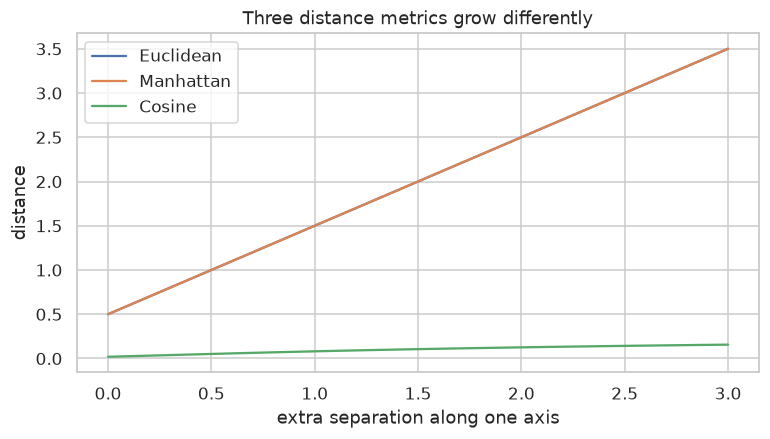

In [1]:
from setup import *
from sklearn.datasets import make_classification

# Visualise the three metrics on a tiny 2-point example as one feature grows.
a = np.array([1.0, 1.0])
b = np.array([1.5, 1.0])
deltas = np.linspace(0, 3, 50)
euc, man, cos = [], [], []
for d in deltas:
 bb = b.copy(); bb[0] += d
 euc.append(np.linalg.norm(a - bb))
 man.append(np.sum(np.abs(a - bb)))
 cos.append(1 - np.dot(a, bb) / (np.linalg.norm(a) * np.linalg.norm(bb)))
plt.plot(deltas, euc, label="Euclidean")
plt.plot(deltas, man, label="Manhattan")
plt.plot(deltas, cos, label="Cosine")
plt.xlabel("extra separation along one axis"); plt.ylabel("distance")
plt.title("Three distance metrics grow differently"); plt.legend(); plt.show()

**Reading the curves:** Euclidean and Manhattan grow steadily with separation,
but they grow *differently* (Euclidean penalises one big diff more, Manhattan
treats all diffs linearly). Cosine saturates near 1 — past a point, separating
along one axis doesn't change the *angle* much, only the magnitude. That's why
cosine is the text‑processing default: document length shouldn't dominate
similarity.

## 3. Worked example A — iris, and choosing k

The iris dataset (150 flowers, 4 measurements, 3 species) is kNN's natural
home: classes are compact, well‑separated clusters. First, *look* at the
separability — if you can see clusters, kNN will work.

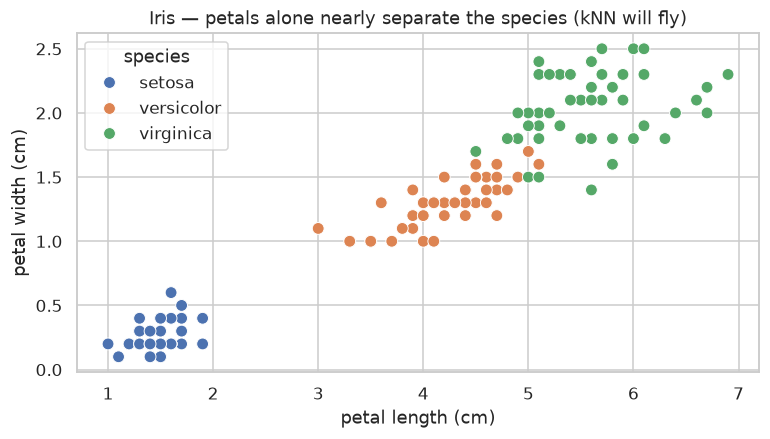

In [2]:
iris = load_iris(as_frame=True)
X, y = iris.data, iris.target
df_iris = X.copy()
df_iris["species"] = y.map({i: n for i, n in enumerate(iris.target_names)})
sns.scatterplot(data=df_iris, x="petal length (cm)", y="petal width (cm)",
 hue="species", palette="deep", s=60)
plt.title("Iris — petals alone nearly separate the species (kNN will fly)")
plt.show()

### Choosing k

`k` controls the **bias–variance trade‑off** (§6):

- **k = 1** → zero training error, wild decision boundaries, high variance
 (overfit). Every point is its own neighbor.
- **k = n** → predict the majority class everywhere, high bias (underfit).
- **Sweet spot** → small odd k (3, 5, 7) found via cross‑validation.

The right way to find it: a **validation curve** — train for many k, plot CV
score vs k, look for the peak/plateau.

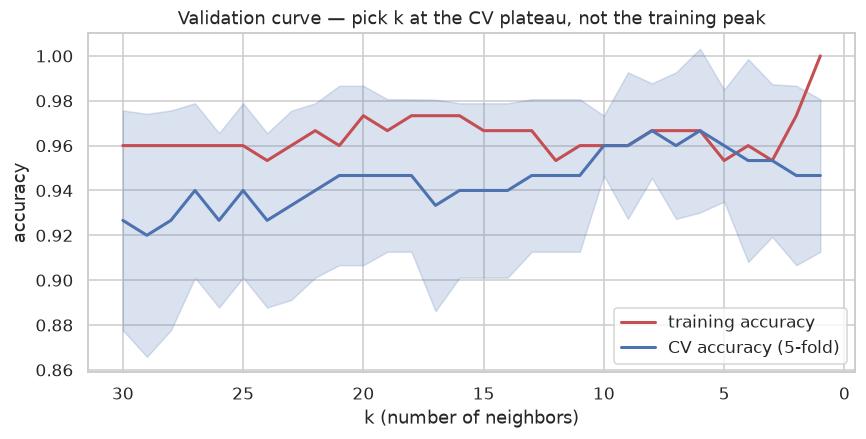

best k by CV: 6 (CV accuracy = 0.967)


In [3]:
# Build a leak‑free pipeline: scaling MUST be inside, see §5.
pipe = Pipeline([("sc", StandardScaler()),
 ("knn", KNeighborsClassifier())])

k_range = np.arange(1, 31)
train_scores, val_scores = validation_curve(
 pipe, X, y, param_name="knn__n_neighbors", param_range=k_range,
 cv=5, scoring="accuracy"
)
# Also compute training accuracy (fit on all data, predict on same data) to
# show the overfitting gap at small k.
train_acc = []
for k in k_range:
 m = Pipeline([("sc", StandardScaler()),
 ("knn", KNeighborsClassifier(n_neighbors=k))])
 m.fit(X, y); train_acc.append(m.score(X, y))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range, train_acc, label="training accuracy", color="#c44e52", lw=2)
ax.plot(k_range, val_scores.mean(axis=1), label="CV accuracy (5-fold)", color="#4c72b0", lw=2)
ax.fill_between(k_range,
 val_scores.mean(axis=1) - val_scores.std(axis=1),
 val_scores.mean(axis=1) + val_scores.std(axis=1),
 alpha=0.2, color="#4c72b0")
ax.set_xlabel("k (number of neighbors)"); ax.set_ylabel("accuracy")
ax.set_title("Validation curve — pick k at the CV plateau, not the training peak")
ax.invert_xaxis() # small k (overfit) on the right
ax.legend(); plt.show()

best_k = k_range[val_scores.mean(axis=1).argmax()]
print(f"best k by CV: {best_k} (CV accuracy = {val_scores.mean(axis=1).max():.3f})")

**How to read the curve (the bias–variance story for kNN):**
- **Left side (large k):** underfitting — CV accuracy is lower because the
 model is too smooth (high bias).
- **Right side (k=1):** training accuracy = 1.0 (it memorised), but CV
 accuracy dips — classic overfitting (high variance).
- **The gap** between the red (train) and blue (CV) curves is your overfitting
 alarm. The best k sits where CV accuracy peaks *and* the gap is small.

> **Odd k for binary classification** avoids ties (k=2 with one neighbor of
> each class is useless). For multiclass, k not divisible by the number of
> classes helps.

## 4. Visualising the decision boundary

kNN's boundary is whatever shape the data demands — it can be very wiggly at
small k, smooth at large k. Let's see it on two features so we can plot it.

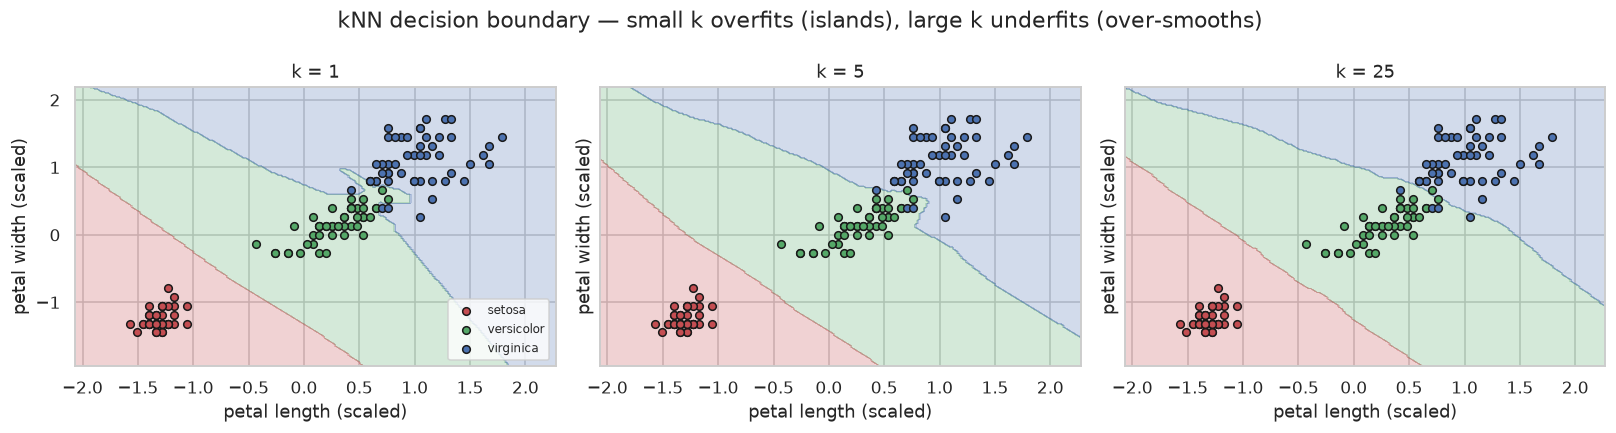

In [4]:
from matplotlib.colors import ListedColormap

def plot_knn_boundary(k, ax):
    X2 = iris.data[["petal length (cm)", "petal width (cm)"]].values
    y2 = iris.target.values
    sc = StandardScaler().fit(X2); X2s = sc.transform(X2)
    m = KNeighborsClassifier(n_neighbors=k).fit(X2s, y2)
    # mesh
    x_min, x_max = X2s[:,0].min()-0.5, X2s[:,0].max()+0.5
    y_min, y_max = X2s[:,1].min()-0.5, X2s[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    cmap = ListedColormap(["#c44e52", "#55a868", "#4c72b0"])
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap)
    for i, name in enumerate(iris.target_names):
        ax.scatter(X2s[y2==i,0], X2s[y2==i,1], c=[cmap(i)], label=name,
                   edgecolor="k", s=25)
    ax.set_title(f"k = {k}")
    ax.set_xlabel("petal length (scaled)"); ax.set_ylabel("petal width (scaled)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, k in zip(axes, [1, 5, 25]):
    plot_knn_boundary(k, ax)
axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle("kNN decision boundary — small k overfits (islands), large k underfits (over‑smooths)")
plt.tight_layout(); plt.show()

**k=1** carves a tiny island around every single point (memorisation — note the
isolated red/green patches). **k=25** oversmooths, merging clusters. **k=5** is
the Goldilocks zone. This is exactly the bias–variance trade‑off (§6.2) made
visible.

## 5. Worked example B — CEO dataset (categorical + mixed scales)

The CEO data is small and mostly categorical — kNN isn't its ideal model, but
that's instructive: it shows kNN's preprocessing needs (one‑hot + scale) on a
real, messy table.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ceo = pd.read_csv("data/ceo_data.csv")
Xc = ceo.drop(columns=["Stock_Market"])
yc = (ceo["Stock_Market"] == "Yes").astype(int)

cat = Xc.select_dtypes(include=["object", "string"]).columns.tolist()
num = Xc.select_dtypes(include=np.number).columns.tolist()
pre = ColumnTransformer([
 ("num", StandardScaler(), num),
 ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
])
pipe_ceo = Pipeline([("pre", pre), ("knn", KNeighborsClassifier(n_neighbors=5))])

scores = cross_val_score(pipe_ceo, Xc, yc, cv=5, scoring="roc_auc")
print(f"CEO kNN (k=5): AUC = {scores.mean():.3f} ± {scores.std():.3f}")
print(f"baseline (guess Yes): {yc.mean():.3f}")

CEO kNN (k=5): AUC = 0.641 ± 0.143
baseline (guess Yes): 0.700


On 60 rows kNN struggles — not enough neighbors per region. That's honest: kNN
needs density, and tiny datasets don't have it. (Notebook 05 covers how to read
a CV mean ± std this wide.)

## 6. Failure case 1 — forgetting to scale (the classic kNN bug)

This is the single most common kNN mistake. Because kNN measures distance, any
feature on a large numeric scale **dominates** the distance computation and the
others become invisible. Scaling (§1.2) is not optional.

We'll build a dataset where one feature is genuinely predictive but on a tiny
scale, and another is pure noise on a huge scale. Without scaling, kNN chases
the noise.

In [6]:
rng = np.random.default_rng(0)
n = 400
signal = rng.normal(0, 1, n) # predictive, scale ~1
noise = rng.normal(0, 1, n) * 1000 # pure noise, scale ~1000
y_bin = (signal + rng.normal(0, 0.5, n) > 0).astype(int)
X_bad = np.column_stack([signal, noise]) # unscaled

X_tr, X_te, y_tr, y_te = train_test_split(X_bad, y_bin, test_size=0.3, random_state=0)

knn_unscaled = KNeighborsClassifier(n_neighbors=5).fit(X_tr, y_tr)
knn_scaled = Pipeline([("sc", StandardScaler()),
 ("knn", KNeighborsClassifier(n_neighbors=5))]).fit(X_tr, y_tr)

print(f"WITHOUT scaling: accuracy = {accuracy_score(y_te, knn_unscaled.predict(X_te)):.3f} (chase the noise)")
print(f"WITH scaling : accuracy = {accuracy_score(y_te, knn_scaled.predict(X_te)):.3f} (find the signal)")

WITHOUT scaling: accuracy = 0.492 (chase the noise)
WITH scaling : accuracy = 0.783 (find the signal)


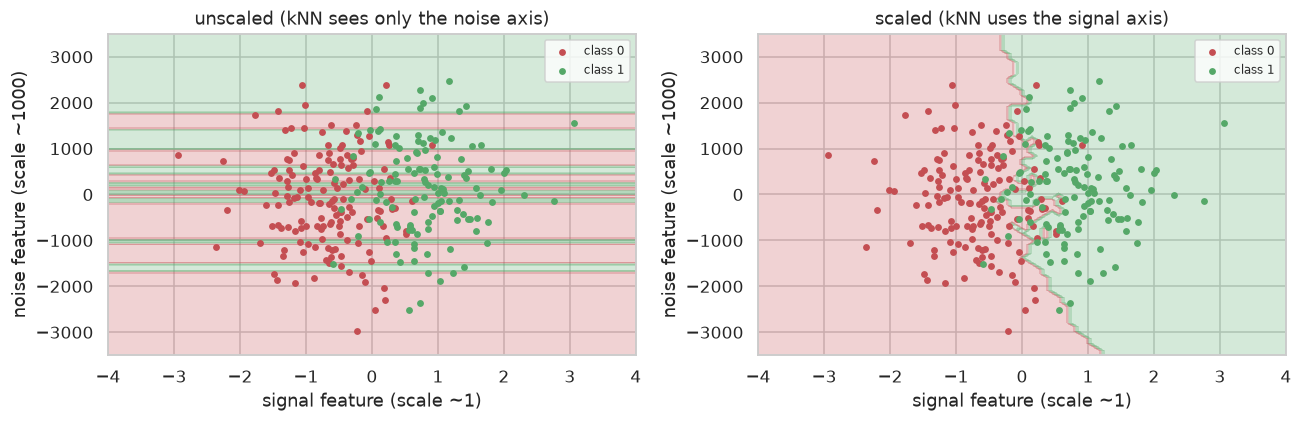

In [7]:
# Visualise: without scaling, the decision boundary ignores the signal feature
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, model, title in zip(ax, [knn_unscaled, knn_scaled],
 ["unscaled (kNN sees only the noise axis)",
 "scaled (kNN uses the signal axis)"]):
    # plot in original (unscaled) coordinates for comparability
    xx, yy = np.meshgrid(np.linspace(-4, 4, 80), np.linspace(-3500, 3500, 80))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    if model is knn_scaled:
        # the scaled pipeline standardises internally; transform grid the same way
        grid_pred = model.predict(grid)
    else:
        grid_pred = model.predict(grid)
    a.contourf(xx, yy, grid_pred.reshape(xx.shape), alpha=0.25,
               cmap=ListedColormap(["#c44e52", "#55a868"]))
    a.scatter(X_tr[y_tr==0,0], X_tr[y_tr==0,1], c="#c44e52", s=12, label="class 0")
    a.scatter(X_tr[y_tr==1,0], X_tr[y_tr==1,1], c="#55a868", s=12, label="class 1")
    a.set_xlabel("signal feature (scale ~1)"); a.set_ylabel("noise feature (scale ~1000)")
    a.set_title(title); a.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

**What just happened (the kNN signature failure):** without scaling, the noise
feature (scale ~1000) dominates every distance computation, so "nearest" is
decided *entirely* by the noise. The boundary becomes a stack of horizontal
bands — kNN is classifying on garbage. With scaling, both features contribute
equally and the boundary tracks the real signal.

> **The rule, full stop:** any distance‑ or gradient‑based model (kNN, SVM, k‑
> means, neural nets, regularised regression) needs scaled features. Tree
> models (notebook 07) are the main exception — they split one feature at a
> time and don't care about scale.

## 7. Failure case 2 — the curse of dimensionality

Add more and more *noise* features and watch kNN degrade even with perfect
scaling. As dimensions pile up, **all pairwise distances converge** — the
"nearest" point is barely nearer than the farthest, so "nearest neighbors"
stops meaning anything.

In [8]:
# Fixed signal (2 informative features), add increasing numbers of noise dims.
dims_to_add = [0, 5, 20, 50, 100, 200]
results = []
for d in dims_to_add:
 X_inf, y_cls = make_classification(
 n_samples=500, n_features=2 + d, n_informative=2, n_redundant=0,
 n_clusters_per_class=1, class_sep=1.0, random_state=0)
 pipe = Pipeline([("sc", StandardScaler()),
 ("knn", KNeighborsClassifier(n_neighbors=7))])
 auc = cross_val_score(pipe, X_inf, y_cls, cv=5, scoring="roc_auc").mean()
 results.append({"noise_dims": d, "total_features": 2 + d, "cv_auc": auc})

res_df = pd.DataFrame(results)
res_df.round(3)

,noise_dims,total_features,cv_auc
0,0,2,0.963
1,5,7,0.901
2,20,22,0.773
3,50,52,0.695
4,100,102,0.625
5,200,202,0.588


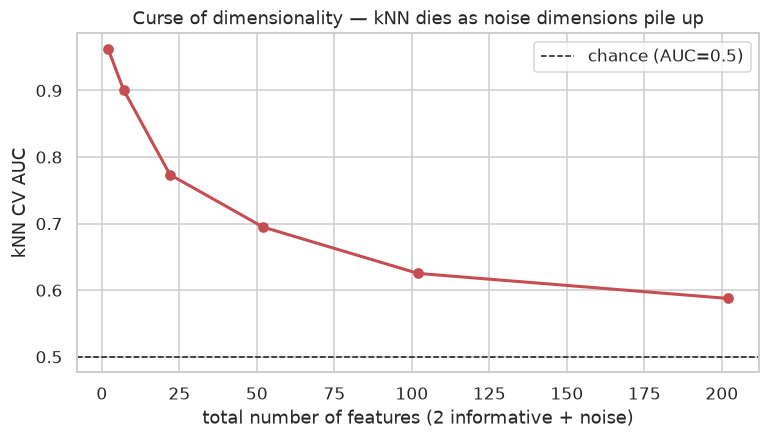

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(res_df["total_features"], res_df["cv_auc"], "o-", color="#c44e52", lw=2)
ax.axhline(0.5, color="k", ls="--", lw=1, label="chance (AUC=0.5)")
ax.set_xlabel("total number of features (2 informative + noise)")
ax.set_ylabel("kNN CV AUC")
ax.set_title("Curse of dimensionality — kNN dies as noise dimensions pile up")
ax.legend(); plt.show()

In [10]:
# Prove *why*: the ratio of nearest-to-farthest distance approaches 1 as dims grow.
from sklearn.metrics import pairwise_distances
rng = np.random.default_rng(1)
ratios = []
for d in [2, 5, 10, 50, 200, 1000]:
 pts = rng.normal(size=(200, d))
 D = pairwise_distances(pts)
 np.fill_diagonal(D, np.inf) # exclude self
 nearest = D.min(axis=1)
 farthest = D.max(axis=1)
 ratios.append({"dims": d, "nearest/farthest ratio": (nearest/farthest).mean()})
pd.DataFrame(ratios).round(3)

,dims,nearest/farthest ratio
0,2,0.0
1,5,0.0
2,10,0.0
3,50,0.0
4,200,0.0
5,1000,0.0


**The smoking gun:** in 2 dimensions the nearest point is on average ~30% as
far as the farthest — there's real *structure* in "nearness". By 1000
dimensions, nearest and farthest are ~99% as far apart. *Everything is
equidistant*, so "k nearest" is a coin flip. The signal drowns in noise
dimensions.

**The cures:**
1. **Feature selection / PCA (notebook 11)** before kNN — drop the noise dims.
2. **Don't reach for kNN on high‑dimensional data** (text, images, many one‑hot
 columns). Use a tree ensemble, a linear model, or a specialised method.
3. **Scale first** — failure case 1, always.

> Rule of thumb from the literature: kNN degrades noticeably past ~10–20
> features without dimensionality reduction.

## Common pitfalls & how to avoid shooting yourself in the foot

1. **Forgetting to scale (§6).** The #1 kNN bug. Always scale inside a
 `Pipeline` — and remember the same applies to SVM, k‑means, neural nets.
2. **Too many features (§7).** The curse of dimensionality is silent — your
 accuracy just slides. If you have >20 features, reduce (PCA) or pick another
 model.
3. **k=1 by default.** That's maximum overfit. Find k via the validation curve,
 not a guess.
4. **Even k in binary classification.** Ties. Use odd k (or let sklearn break
 them, but know it's arbitrary).
5. **Treating kNN as "fast".** Training is instant, but *prediction* scans all
 training data — slow and memory‑heavy at scale. Use FAISS/Annoy/HNSW in
 production.
6. **Categorical features without one‑hot.** kNN can't measure "distance"
 between `Banking` and `Health Care` directly. One‑hot first (notebook 03).
7. **Imbalanced classes with plain majority vote.** The majority class wins
 every tie. Use `weights="distance"` or a stratified metric.

## Exercises

1. **Metric choice.** You're building a "similar articles" feature for a news
 site using bag‑of‑words vectors. Which distance metric, and why? (Hint:
 what should *not* matter — the article's length, or its topic?)
2. **Find k on the breast‑cancer dataset.** Load it with
 `load_breast_cancer(as_frame=True)`, build a scaled kNN pipeline, and draw
 the validation curve for k=1..30. What k does CV pick? Is it the same as
 iris?
3. **Scaling, quantified.** In the §6 example, swap `StandardScaler` for
 `MinMaxScaler`. Does the result change? Why or why not? (Both put features
 on comparable scales — the point is comparability, not the specific range.)
4. **Curse of dimensionality, felt.** In §7, instead of adding *noise*
 dimensions, add *informative* ones (set `n_informative=2+d`). Does accuracy
 still fall? What does that tell you about *which* dimensions cause the curse?
5. **kNN regression.** `KNeighborsRegressor` exists too. On the Ames dataset
 (notebook 03/04), compare kNN regression (scaled, k chosen by CV) vs the
 Ridge baseline. When does each win?

<details><summary>Answers (click to expand)</summary>

```python
# 1: Cosine. Bag-of-words magnitude = article length, which shouldn't drive
# similarity; cosine ignores magnitude and compares only the topic mix (the
# direction of the vector).

# 2
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer(as_frame=True)
Xb, yb = bc.data, bc.target
tr, va = validation_curve(Pipeline([("sc",StandardScaler()),
 ("knn",KNeighborsClassifier())]),
 Xb, yb, param_name="knn__n_neighbors",
 param_range=range(1,31), cv=5, scoring="roc_auc")
print("best k:", list(range(1,31))[va.mean(axis=1).argmax()]) # often ~5-9

# 3: Result is essentially the same. Both make features comparable; the specific
# range (z-scores in [-3,3] vs [0,1]) rarely matters for kNN. What matters
# is that no single feature dominates the distance.

# 4: With informative dimensions added, accuracy does NOT collapse (it may even
# rise). The curse comes from NOISE dimensions — features that contribute to
# the distance but carry no signal, diluting the real structure.

# 5
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
# kNN wins when the target is a smooth, local function of features with few
# dimensions; Ridge wins when features are many and the relationship is
# roughly linear / global. On Ames (many features, partly linear) Ridge
# usually wins; kNN competes only after PCA + careful scaling.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §1.2
 (variance/spread & scaling), §6 (bias–variance trade‑off in choosing k).
- Textbook: Boehmke & Greenwell, *HOML*, Ch. 8 —
 <https://bradleyboehmke.github.io/HOML/knn.html>.
- Beyer et al. (1999), *When is "Nearest Neighbor" Meaningful?* — the classic
 proof that distances converge in high dimensions.
- Radovanović et al. (2010), *Hubs in Space*, JMLR — the "hubness" phenomenon.
- GeeksforGeeks, *kNN and the Curse of Dimensionality*:
 <https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbors-and-curse-of-dimensionality/>.